In [1]:
!pip install opencv-python

# !sudo apt install tesseract-ocr tesseract-ocr-rus # Install Tesseract OCR engine
!pip install pytesseract         # Install Python wrapper

In [2]:
# Add the Tesseract PPA (for Ubuntu 22.04 - Colab's current base)
!sudo add-apt-repository ppa:alex-p/tesseract-ocr-devel -y
!sudo apt-get update

# Install the latest Tesseract (5.x) with language packs
!sudo apt-get install tesseract-ocr -y  # Core engine
!sudo apt-get install libtesseract-dev -y  # Development files
!sudo apt-get install tesseract-ocr-eng -y  # English language data
!sudo apt-get install tesseract-ocr-osd -y  # Script and orientation detection
!sudo apt-get install tesseract-ocr-rus -y  # Script and orientation detection

Repository: 'deb https://ppa.launchpadcontent.net/alex-p/tesseract-ocr-devel/ubuntu/ jammy main'
Description:
This PPA contains an OCR engine - libtesseract and a command line program - tesseract. The development version available here (currntly 5.0.0 ) is better in many aspects (functionality, speed, stability) but is not 100 % API compatible with version 4.0. Tesseract 4 added a new neural net (LSTM) based OCR engine which is focused on line recognition, but also still supports the legacy Tesseract OCR engine of Tesseract 3 which works by recognizing character patterns. Compatibility with Tesseract 3 is enabled by using the Legacy OCR Engine mode (--oem 0). It also needs traineddata files which support the legacy engine, for example those from the tessdata repository. Tesseract has unicode (UTF-8) support, and can recognize more than 100 languages "out of the box". Tesseract supports various output formats: plain text, hOCR (HTML), PDF, invisible-text-only PDF, TSV. The master branch

In [3]:
from google.colab.patches import cv2_imshow

!pip install easyocr
import easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.8/422.8 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [4]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = "/usr/bin/tesseract"

!tesseract --version  # Check Tesseract version
print(pytesseract.get_tesseract_version())  # Verify pytesseract access

tesseract 5.5.0
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX2
 Found AVX
 Found FMA
 Found SSE4.1
 Found OpenMP 201511
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8
 Found libcurl/7.81.0 OpenSSL/3.0.2 zlib/1.2.11 brotli/1.0.9 zstd/1.4.8 libidn2/2.3.2 libpsl/0.21.0 (+libidn2/2.3.2) libssh/0.9.6/openssl/zlib nghttp2/1.43.0 librtmp/2.3 OpenLDAP/2.5.17
5.5.0


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
from pathlib import Path


In [7]:
root = Path('/content/drive/MyDrive')
imgs_path = root / 'src_filtered_results'

In [9]:
img_path = imgs_path / '457242852.jpg'

In [8]:
import cv2
import numpy as np

array([[150, 150, 151, ..., 174, 175, 175],
       [150, 150, 151, ..., 173, 173, 173],
       [149, 150, 151, ..., 174, 173, 172],
       ...,
       [109, 112, 112, ...,  95, 108, 106],
       [110, 114, 114, ..., 112, 105, 106],
       [107, 112, 113, ..., 104, 101, 106]], dtype=uint8)
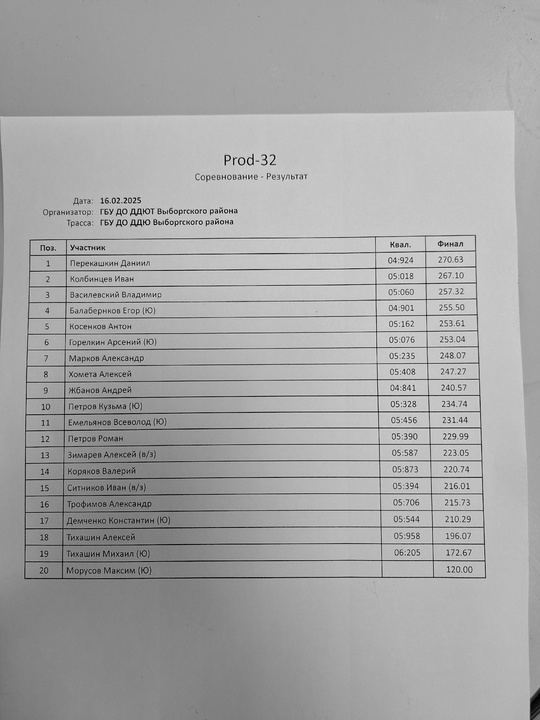

In [10]:
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
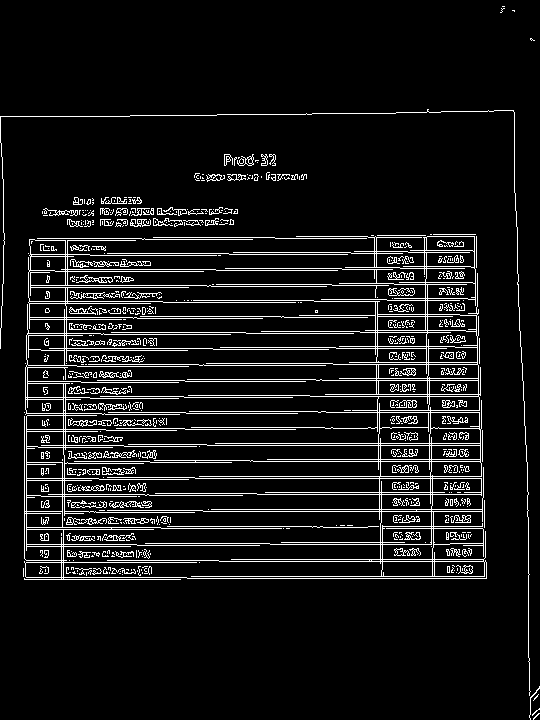

In [11]:
# Step 4: Apply Canny edge detection
edges = cv2.Canny(gray, 50, 150, apertureSize=3)
edges


array([[[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       ...,

       [[102, 106, 117],
        [105, 109, 120],
        [107, 109, 120],
        ...,
        [ 47,  87, 129],
        [ 57, 100, 143],
        [ 53,  98, 142]],

       [[103, 107, 118],
        [107, 111, 122],
        [109, 111, 122],
        ...,
        [ 61, 103, 148],
        [ 48,  97, 143],
        [ 48,  98, 144]],

       [[100, 104, 115],
        [105, 109, 120],
        [108, 110, 121],
        ...,
        [ 51,  96, 140],
        [ 43,  92, 140],
        [ 46,  98, 145]]], dtype=uint8)
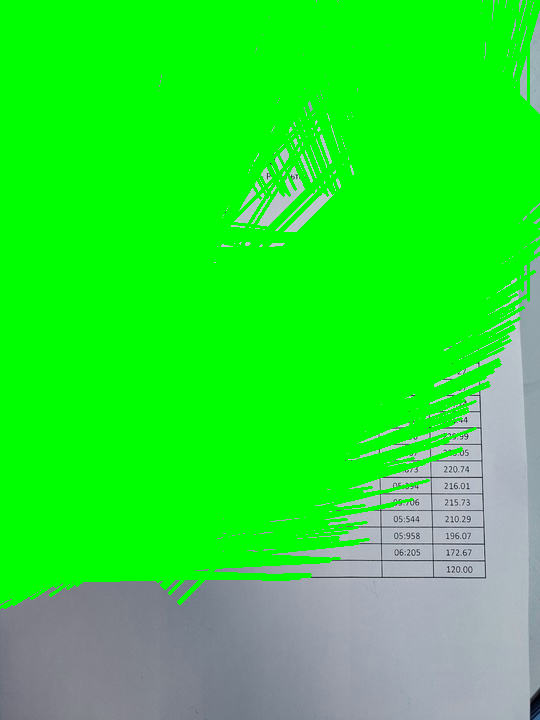

In [12]:

# Step 5: Use Hough Transform to detect lines
lines = cv2.HoughLines(edges, 1, np.pi / 180, threshold=100)

# Step 6: Draw the lines on the original image
if lines is not None:
    llen =300
    for rho, theta in lines[:, 0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + llen * (-b))
        y1 = int(y0 + llen * (a))
        x2 = int(x0 - llen * (-b))
        y2 = int(y0 - llen * (a))
        cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

img

5189.5
5171.0
5118.0
5113.0
5041.5
5032.5
4985.0
5002.0
4947.5
4809.5
4787.5
4773.0
4749.5
4788.5
4683.0
4700.0
4701.5
4740.5
4730.5
4715.5
4628.0


array([[[134, 150, 156],
        [134, 150, 156],
        [135, 151, 157],
        ...,
        [155, 174, 181],
        [156, 175, 182],
        [156, 175, 182]],

       [[134, 150, 156],
        [134, 150, 156],
        [135, 151, 157],
        ...,
        [154, 173, 180],
        [154, 173, 180],
        [154, 173, 180]],

       [[133, 149, 155],
        [134, 150, 156],
        [135, 151, 157],
        ...,
        [155, 174, 181],
        [154, 173, 180],
        [153, 172, 179]],

       ...,

       [[102, 106, 117],
        [105, 109, 120],
        [107, 109, 120],
        ...,
        [ 47,  87, 129],
        [ 57, 100, 143],
        [ 53,  98, 142]],

       [[103, 107, 118],
        [107, 111, 122],
        [109, 111, 122],
        ...,
        [ 61, 103, 148],
        [ 48,  97, 143],
        [ 48,  98, 144]],

       [[100, 104, 115],
        [105, 109, 120],
        [108, 110, 121],
        ...,
        [ 51,  96, 140],
        [ 43,  92, 140],
        [ 46,  98, 145]]], dtype=uint8)
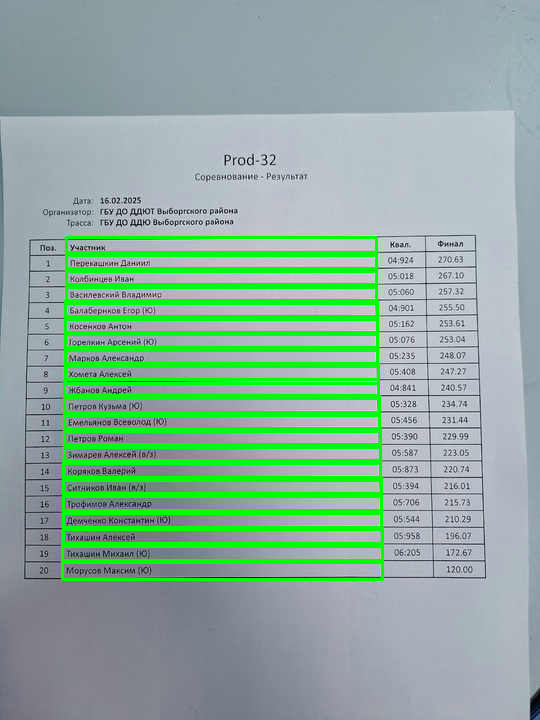

In [13]:
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

# Detect horizontal/vertical lines
kernel_h = np.ones((1, 20), np.uint8)
kernel_v = np.ones((20, 1), np.uint8)
horizontal = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_h)
vertical = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_v)

# Combine lines
grid = cv2.add(horizontal, vertical)

cells = []
# Find contours of cells
contours, _ = cv2.findContours(grid, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    area = cv2.contourArea(cnt)
    if area < 2000 or area > 10000:
      continue
    print(area)
    cells.append((x,y,w,h))
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)  # Highlight cell

img

In [14]:
allowable_chars = "абвгдеёжзийклмнопрстуфхцчшщъыэюя"
allowable_chars += allowable_chars.upper()
allowable_chars += " "
#print(allowable_chars)

for cell in sorted(cells, key=lambda a: (a[1], a[0])):
  x,y,w,h = cell
  cell_img = gray[y:y+h, x:x+w]
  cell_text = pytesseract.image_to_string(cell_img, config=f"-c tessedit_char_whitelist={allowable_chars} -c preserve_interword_spaces=1", lang='rus')
  print(cell_text.strip())
  print()



ПерекашкинДвниил

КолбинцевИван

эсилевскийВладимир

злэбернновЕгорЮ

КосенковАнтон

ГорелкинАрсенийЮ

марновАлександр

ХометаАленсей

бэновАндрей

ПетровКузыиаЮ

ГЕмеляновВсеволодЮ

петровРоман

ГЗимаревАлексейвз

КоряковВалерий

СитниковИвзнвуз

рофимовАленсандр

ДемченкоКонстантинЮ

ТихашинАлексей

ТихашинМихаилЮ

МорисовМансимЮ



Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.1% Complete

не ООО ООО ООО

psm 7 'не ООО ООО ООО'


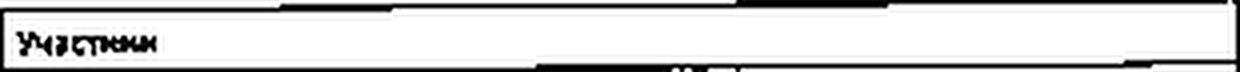

ООО
хабпим



| Перекашкин Даниил
psm 7 'ООО ОИ'


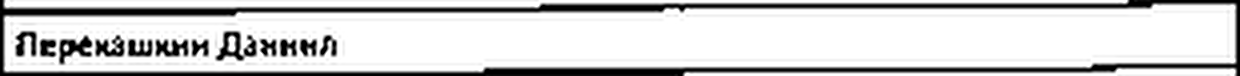


Перекзшкни Даяння



[ Колбинцев Иван.
psm 7 'он Ооо]'


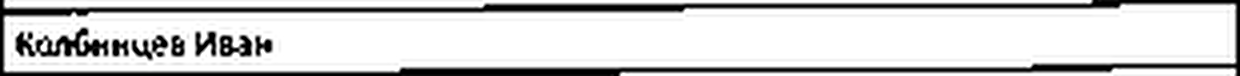


КолСннчев ИВаЮ



| эсилевский Владимир
psm 7 ''


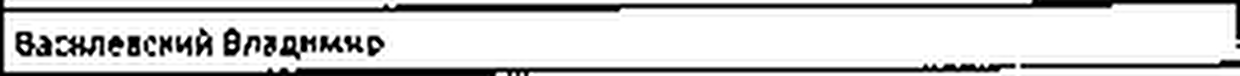

| Васвлевский Владимир |
Вазнлевскин Вп:днихо


[6злэберннов Егор (Ю).
[6злэберннов Егор (Ю).
psm 7 '[6злэберннов Егор (Ю).'


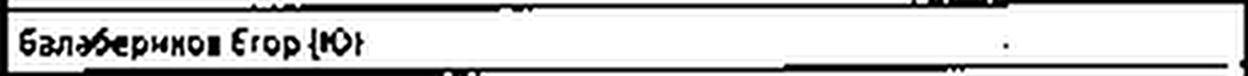

бзлоберннов Егор {ЮР ; |
БзлаБсрнког €тор {Ю}


ООО
`Косенков Антон.
psm 7 'ООО'


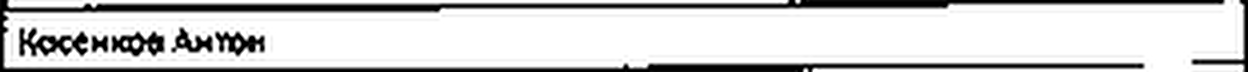

венков Ан
Касенк Аннож


[Горелкин Арсений (Ю}
[Горелкин Арсений (Ю}
psm 7 '[Горелкин Арсений (Ю}'


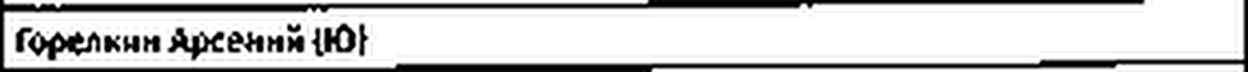

| Горелкин Ареенни{Ю! |
(Фрулкнн Яркеннй {Ю}



| марнов Александр.
psm 7 ''


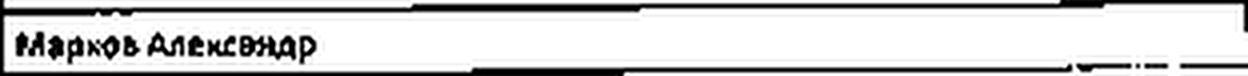


{аркоь Алексонар



[Комета Алексей,
psm 7 ''


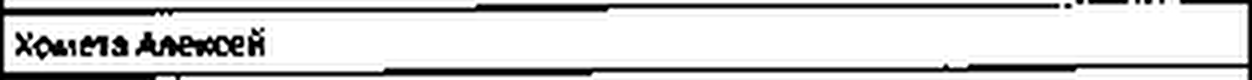

| Хомлела Алексей |
ховиз длеясен



|бэнов Андрей _
psm 7 ''


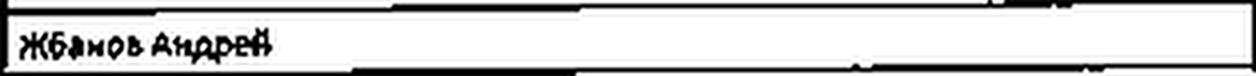


Жбаноь днрреф


"Петров Кузыиа (Ю)
"Петров Кузыиа (Ю)
psm 7 '"Петров Кузыиа (Ю)'


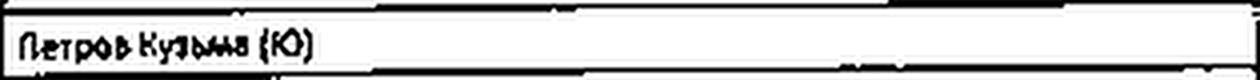

| Петров Кузьма (Ю) |
Петроь Куы {Ю)


[Емельянов Всеволод (Ю). м
[Емельянов Всеволод (Ю).
psm 7 '[Емельянов Всеволод (Ю). м'


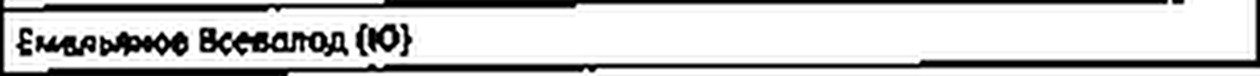

|Емальяное Всевапод (Ю} | |
Емаяыоюо Вевалод (Ю}



[петров Роман.
psm 7 ''


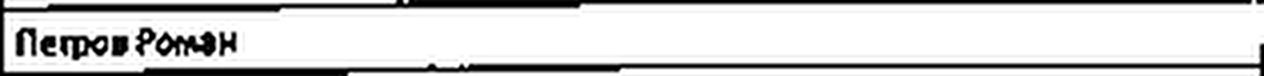

| Петров ?отиэн
Пепюв Роэн


ГЗимарев Алексей (в/3) Ш.
ГЗимарев Алексей (в/3)
psm 7 'ГЗимарев Алексей (в/3) Ш.'


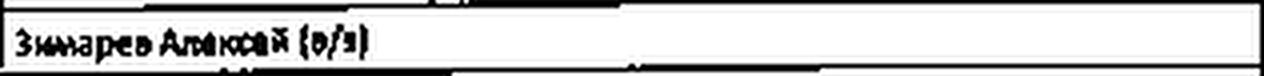

| Зимарев Алёксай (9/1) |
Зимарсь Акын {о3}


`Коряков Валерий.
`Коряков Валерий.
psm 7 '`Коряков Валерий.'


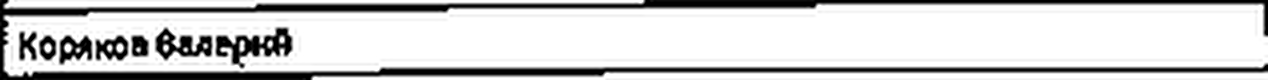

| Корлков алеркв |
Кориков бальрж


[Ситников Иван (в/з). в ]
[Ситников Иван (в/з).
psm 7 '[Ситников Иван (в/з). в ]'


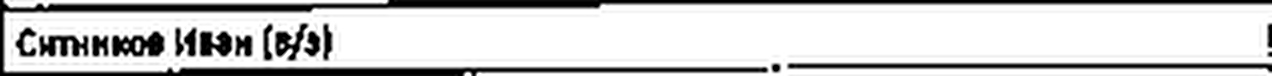

| Сятннкое Мизн (573} . |
Сннксв Яюн (Чэ


| рофимов Аленсандр.
| рофимов Аленсандр.
psm 7 '| рофимов Аленсандр.'


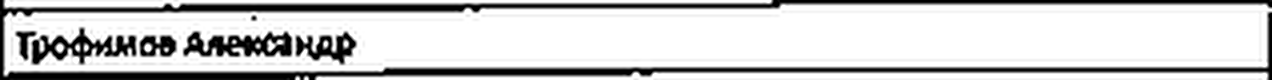

| Трофимов Александр НИ
Тфино Алекаанар



[Демченко Константин (Ю).
psm 7 ''


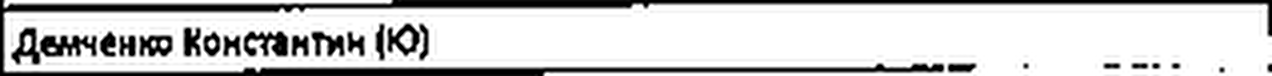

Демченко Константин (Ю) оо. о
Денченка Консаантин [Ю)



Тихашин Алексей.
psm 7 ''


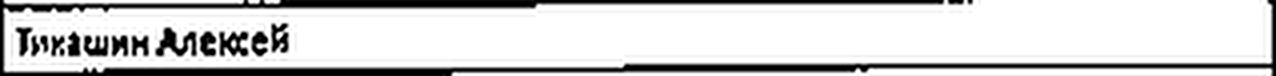

| Тикашин Алекей |
Тнкшин Алскей



`Тихашин Михаил (Ю).
psm 7 ''


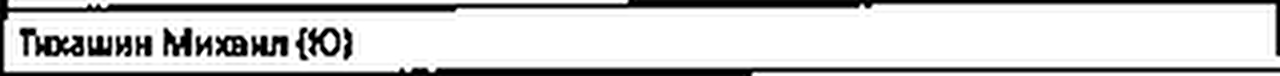

| Тихашин Михвнл {©} |
Тнхяшян Миханл {Ю}



`Морисов Максим (Ю}.
psm 7 ''


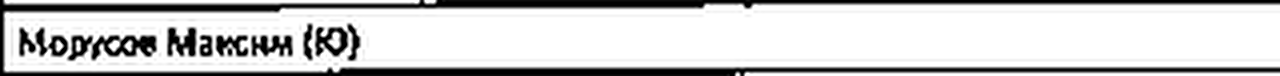

| Морусов Макснм (®} пи
^ви  € Максня (Ю}


In [15]:
reader = easyocr.Reader(["ru"])  # English

for cell in sorted(cells, key=lambda a: (a[1], a[0])):
  x,y,w,h = cell
  cell_img = gray[y:y+h, x:x+w]
  _, otsu_thresh = cv2.threshold(
      cell_img,
      0,                  # Threshold value (ignored when using Otsu)
      255,                # Max value for pixels above threshold
      cv2.THRESH_BINARY + cv2.THRESH_OTSU  # Combine binary threshold + Otsu
  )
  cv2_imshow(cell_img)
  cell_text = pytesseract.image_to_string(cell_img, config='--psm 6', lang='rus')
  print(cell_text.strip())
  cell_text = pytesseract.image_to_string(cell_img, lang='rus')
  print(cell_text.strip())

  cell_text = pytesseract.image_to_string(cell_img, config="--psm 7", lang='rus')
  print("psm 7", repr(cell_text.strip()))
  otsu_thresh = cv2.resize(otsu_thresh, None, fx=4, fy=4, interpolation=cv2.INTER_LANCZOS4)
  # otsu_thresh = cv2.fastNlMeansDenoising(otsu_thresh, h=10)
  cv2_imshow(otsu_thresh)
  cell_text = pytesseract.image_to_string(otsu_thresh, config='--psm 6', lang='rus')
  print(cell_text.strip())
  res = reader.readtext(otsu_thresh)
  for r in res:
    print(r[1])

In [16]:
reader = easyocr.Reader(["ru"])  # English

cell_images = []

for cell in sorted(cells, key=lambda a: (a[1], a[0])):
  x,y,w,h = cell
  cell_img = gray[y:y+h, x:x+w]
  cell_images.append(cell_img)
  # _, otsu_thresh = cv2.threshold(
  #     cell_img,
  #     0,                  # Threshold value (ignored when using Otsu)
  #     255,                # Max value for pixels above threshold
  #     cv2.THRESH_BINARY + cv2.THRESH_OTSU  # Combine binary threshold + Otsu
  # )
  # cv2_imshow(cell_img)
  # cell_text = pytesseract.image_to_string(cell_img, config='--psm 6', lang='rus')
  # print(cell_text.strip())
  # cell_text = pytesseract.image_to_string(cell_img, lang='rus')
  # print(cell_text.strip())

  # cell_text = pytesseract.image_to_string(cell_img, config="--psm 7", lang='rus')
  # print("psm 7", repr(cell_text.strip()))
  # otsu_thresh = cv2.resize(otsu_thresh, None, fx=4, fy=4, interpolation=cv2.INTER_LANCZOS4)
  # # otsu_thresh = cv2.fastNlMeansDenoising(otsu_thresh, h=10)
  # cv2_imshow(otsu_thresh)
  # cell_text = pytesseract.image_to_string(otsu_thresh, config='--psm 6', lang='rus')
  # print(cell_text.strip())
  # res = reader.readtext(otsu_thresh)
  # for r in res:
  #   print(r[1])

In [17]:
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt


def crop_image(img, sigma=3, padding=5, threshold_ratio=0.1):
    thresh = img.copy()
      # Vertical projection (sum of pixels per column)
    vertical_proj = np.sum(thresh, axis=0)

    # Smooth the projection to ignore small artifacts
    smoothed = gaussian_filter1d(vertical_proj.astype(float), sigma=sigma)

    # Normalize and threshold
    max_val = np.max(smoothed)
    if max_val == 0:  # No text found
        return img

    threshold = max_val * threshold_ratio
    threshold = np.quantile(vertical_proj, 0.5)
    mask = smoothed > threshold

    # cv2_imshow(thresh)

    # plt.figure(figsize=(8, 6))
    # plt.bar(range(len(vertical_proj)), vertical_proj)
    # plt.title('Array Values as Bars')
    # plt.xlabel('Index')
    # plt.ylabel('Value')
    # plt.grid(True, alpha=0.3)
    # plt.show()

    # breakpoint()

    # Find start and end of text region
    if np.any(mask):
        x_start = np.argmax(mask)
        x_end = len(mask) - np.argmax(mask[::-1]) - 1
        print(f"{x_start = }, {x_end = }, {img.shape[1] = }")
    else:
        x_start, x_end = 0, img.shape[1]  # Fallback to full width

    # Apply padding
    # x_start = max(0, x_start - padding)
    # x_end = min(img.shape[1], x_end + padding)

    return x_start
    return img[:, :x_start]
    # return img[:, x_start:x_end]

Make threshold and binary image. Use it to crop the image so that the text is mainly present, not the text and lots of empty cell space. Get the left-most postition of the empty space in cell and return it.

Then, crop the original image using the obtained position. You got the better OCR result, Voila!

Adaptive threshold with larger window and kernel size removes the noise (dots) better: compared 11, 2 and 21, 10. The latter did the job better

image as is ''


cleaned ''
x_start = np.int64(44), x_end = np.int64(305), img.shape[1] = 310


cropped ''


athreshold ''


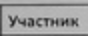

resize ''


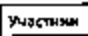

resize cropped ''




image as is '| Перекашкин Даниил'


cleaned '"Перекашини Дуничл'
x_start = np.int64(85), x_end = np.int64(305), img.shape[1] = 310


cropped ''


athreshold '[ Перекашким Даниил'


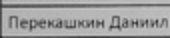

resize 'Перекашкин Даниил'


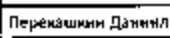

resize cropped ''




image as is '[ Колбинцев Иван.'


cleaned '|потбныцев Ивэн.'
x_start = np.int64(70), x_end = np.int64(305), img.shape[1] = 310


cropped ''


athreshold ''


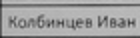

resize 'Колбинцев Иван'


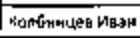

resize cropped ''




image as is '| эсилевский Владимир'


cleaned ''
x_start = np.int64(169), x_end = np.int64(300), img.shape[1] = 310


cropped ''


athreshold ''


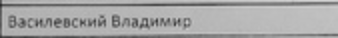

resize 'Василевский Владимир'


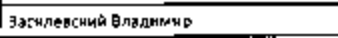

resize cropped ''




image as is '[6злэберннов Егор (Ю).'


cleaned '| болабериноо Егор О'
x_start = np.int64(142), x_end = np.int64(307), img.shape[1] = 312


cropped '`баляберинов Егор'


athreshold '[6злэберннов Егор (Ю)'


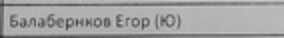

resize ''


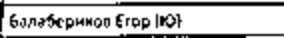

resize cropped ''




image as is '`Косенков Антон.'


cleaned ''
x_start = np.int64(121), x_end = np.int64(307), img.shape[1] = 312


cropped ''


athreshold ''


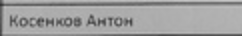

resize ''


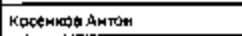

resize cropped 'Косенко'




image as is '[Горелкин Арсений (Ю}'


cleaned 'ГГорелкин Арсений ВОТ'
x_start = np.int64(93), x_end = np.int64(307), img.shape[1] = 312


cropped ''


athreshold 'Торелкин Арсений (Ю)'


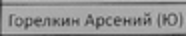

resize 'Горелкин Арсений (Ю)'


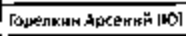

resize cropped ''




image as is '| марнов Александр.'


cleaned ''
x_start = np.int64(80), x_end = np.int64(306), img.shape[1] = 312


cropped ''


athreshold ''


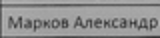

resize 'Марков Александр'


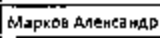

resize cropped ''




image as is '[Комета Алексей,'


cleaned ''
x_start = np.int64(66), x_end = np.int64(309), img.shape[1] = 313


cropped ''


athreshold '[Комета АЛенсей'


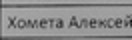

resize 'Хомета Алексей'


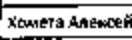

resize cropped 'ро\n\nХолмета Аленсей'




image as is '|бэнов Андрей _'


cleaned 'ибзнов дндреЯ'
x_start = np.int64(69), x_end = np.int64(305), img.shape[1] = 314


cropped ''


athreshold ''


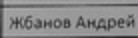

resize 'Жбэнов Андрей'


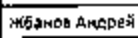

resize cropped ''




image as is '"Петров Кузыиа (Ю)'


cleaned '[Петроя Кузыдь (©)'
x_start = np.int64(79), x_end = np.int64(310), img.shape[1] = 315


cropped ''


athreshold '"Петров Кузьма (Ю)'


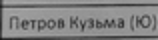

resize 'Петров Кузьма (Ю)'


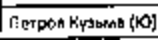

resize cropped ''




image as is '[Емельянов Всеволод (Ю).'


cleaned 'ГЕмальянов Веваслод {К}'
x_start = np.int64(146), x_end = np.int64(307), img.shape[1] = 315


cropped '`Бмельйнов Веваслод {К}'


athreshold 'мель'


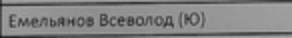

resize 'Емельянов Всеволод (Ю}'


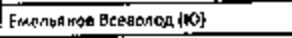

resize cropped '| Еидльйнов Вееаолед {Ю}'




image as is '[петров Роман.'


cleaned 'Глетрою Роман.'
x_start = np.int64(74), x_end = np.int64(310), img.shape[1] = 316


cropped ''


athreshold ''


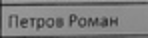

resize 'Петров Роман'


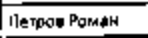

resize cropped ''




image as is 'ГЗимарев Алексей (в/3)'


cleaned ''
x_start = np.int64(97), x_end = np.int64(309), img.shape[1] = 316


cropped ''


athreshold ''


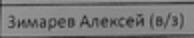

resize ''


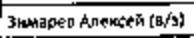

resize cropped 'А.\nЗнмарес Алексей (в/3)'




image as is '`Коряков Валерий.'


cleaned 'ГКоранав Валернй.'
x_start = np.int64(195), x_end = np.int64(310), img.shape[1] = 317


cropped ''


athreshold '`Коряков Валерий.'


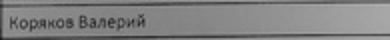

resize 'Коряков Валерий'


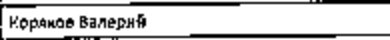

resize cropped '] Коранае Валернй'




image as is '[Ситников Иван (в/з).'


cleaned ''
x_start = np.int64(92), x_end = np.int64(309), img.shape[1] = 318


cropped ''


athreshold ''


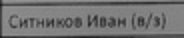

resize 'Ситников Ивам (8/3)'


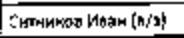

resize cropped 'икоз Ивам (^/3}'




image as is '| рофимов Аленсандр.'


cleaned '[рофимав Аленсандр. |'
x_start = np.int64(195), x_end = np.int64(312), img.shape[1] = 318


cropped ''


athreshold ''


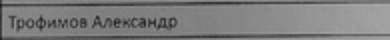

resize 'Трофимов Аленсандр'


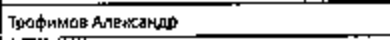

resize cropped 'Трафимав Алеаандр'




image as is '[Демченко Константин (Ю).'


cleaned "'демченно Комстаитин (©."
x_start = np.int64(142), x_end = np.int64(304), img.shape[1] = 318


cropped ''


athreshold '[Демченко Константин (Ю).'


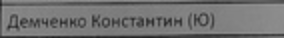

resize 'Демченко Константин (Ю)'


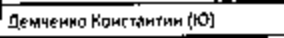

resize cropped ''




image as is 'Тихашин Алексей.'


cleaned ''
x_start = np.int64(100), x_end = np.int64(313), img.shape[1] = 319


cropped ''


athreshold ''


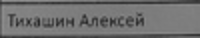

resize '`Тихашин Алексей'


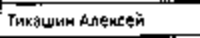

resize cropped '`Тикзшим дленеей'




image as is '`Тихашин Михаил (Ю).'


cleaned 'Тихашин Михэнл ©).'
x_start = np.int64(102), x_end = np.int64(314), img.shape[1] = 320


cropped ''


athreshold '`Тихашин Михаил (Ю).'


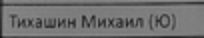

resize 'Тихашин Михаил {Ю)'


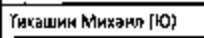

resize cropped ''




image as is '`Морисов Максим (Ю}.'


cleaned '‘орусоз Максим (КИ'
x_start = np.int64(92), x_end = np.int64(314), img.shape[1] = 320


cropped ''


athreshold '`Морисов Максим (Ю}'


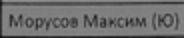

resize 'Морусов Максим (Ю}'


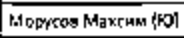

resize cropped ''




In [18]:
for cell_image in cell_images:
  cimg = cell_image.copy()
  cv2_imshow(cimg)
  txt = pytesseract.image_to_string(cimg, lang='rus')
  print(f"image as is {txt.strip()!r}")

  c = cv2.adaptiveThreshold(
    cimg, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
  )
  cv2_imshow(c)

  c = cv2.adaptiveThreshold(
    cimg, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2
  )
  cv2_imshow(c)

  c = cv2.adaptiveThreshold(
    cimg, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 10
  )
  cv2_imshow(c)

  c = cv2.adaptiveThreshold(
    cimg, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 21,10
  )
  cv2_imshow(c)

  cimg = c.copy()

  kernel = np.ones((3,3), np.uint8)  # Adjust kernel size based on dot size
  cleaned = cv2.fastNlMeansDenoising(cimg)
  # cleaned = cv2.morphologyEx(cimg, cv2.MORPH_OPEN, kernel, iterations=1)
  cv2_imshow(cleaned)
  txt = pytesseract.image_to_string(cleaned, lang="rus")
  print(f"cleaned {txt.strip()!r}")

  x_start = crop_image(cimg.copy())
  crimg = cimg.copy()
  crimg = crimg[:, :x_start]
  cv2_imshow(crimg)
  txt = pytesseract.image_to_string(crimg, lang="rus")
  print(f"cropped {txt.strip()!r}")

  cimg = cell_image.copy()
  cimg=  cimg[:, :x_start]

  # cimg =

  cv2_imshow(cimg)
  txt = pytesseract.image_to_string(cimg, lang='rus')
  print(f"athreshold {txt.strip()!r}")

  scale_by = 2
  new_dim = (cimg.shape[1]*scale_by, cimg.shape[0]*scale_by)
  cimg = cv2.resize(cimg, new_dim, interpolation=cv2.INTER_LINEAR)
  cv2_imshow(cimg)
  txt = pytesseract.image_to_string(cimg, lang='rus')
  print(f"resize {txt.strip()!r}")

  scale_by = 2
  new_dim = (crimg.shape[1]*scale_by, crimg.shape[0]*scale_by)
  crimg = cv2.resize(crimg, new_dim, interpolation=cv2.INTER_LINEAR)
  cv2_imshow(crimg)
  txt = pytesseract.image_to_string(crimg, lang='rus')
  print(f"resize cropped {txt.strip()!r}")

  print()
  print()


In [19]:
!pip install thefuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.4 MB/s eta 0:00:00


In [20]:
from thefuzz import process

ocr_text = "Тихашин Михэнл"
possible_fullnames = [
    "Перекашкин Даниил",
    "Колбинцев Иван",
    "Василевский Владимир",
    "Балабериков Егор",
    "Косенков Антон",
    "Горелкин Арсений",
    "Марков Александр",
    "Хомета Аленсей",
    "Жбанов Андрей",
    "Петров Кузыма",
    "Емельянов Всеволод",
    "Петров Роман",
    "Зимарев Алексей",
    "Коряков Валерий",
    "Ситников Иван",
    "Трофимов Александр",
    "Демченко Константин",
    "Тихашин Алексей",
    "Тихашин Михаил",
    "Морусов Максим",
]
allowable_chars = "абвгдеёжзийклмнопрстуфхцчшщъыэюя"
allowable_chars += allowable_chars.upper()
allowable_chars += " "
#print(allowable_chars)

for cell in sorted(cells, key=lambda a: (a[1], a[0])):
  x,y,w,h = cell
  cell_img = gray[y:y+h, x:x+w]
  cell_text = pytesseract.image_to_string(cell_img, config=f"-c tessedit_char_whitelist={allowable_chars} -c preserve_interword_spaces=1", lang='rus')
  print(cell_text.strip(), process.extractOne(cell_text.strip(), possible_fullnames))
  print()

print(process.extractOne(ocr_text, possible_fullnames))

 ('Перекашкин Даниил', 0)

ПерекашкинДвниил ('Перекашкин Даниил', 91)

КолбинцевИван ('Колбинцев Иван', 96)

эсилевскийВладимир ('Василевский Владимир', 89)

злэбернновЕгорЮ ('Балабериков Егор', 65)

КосенковАнтон ('Косенков Антон', 96)

ГорелкинАрсенийЮ ('Горелкин Арсений', 94)

марновАлександр ('Марков Александр', 90)

ХометаАленсей ('Хомета Аленсей', 96)

бэновАндрей ('Жбанов Андрей', 83)

ПетровКузыиаЮ ('Петров Кузыма', 85)

ГЕмеляновВсеволодЮ ('Емельянов Всеволод', 89)

петровРоман ('Петров Роман', 96)

ГЗимаревАлексейвз ('Зимарев Алексей', 88)

КоряковВалерий ('Коряков Валерий', 97)

СитниковИвзнвуз ('Ситников Иван', 79)

рофимовАленсандр ('Трофимов Александр', 88)

ДемченкоКонстантинЮ ('Демченко Константин', 95)

ТихашинАлексей ('Тихашин Алексей', 97)

ТихашинМихаилЮ ('Тихашин Михаил', 93)

МорисовМансимЮ ('Морусов Максим', 79)

('Тихашин Михаил', 86)


Parse header

array([[[134, 150, 156],
        [134, 150, 156],
        [135, 151, 157],
        ...,
        [155, 174, 181],
        [156, 175, 182],
        [156, 175, 182]],

       [[134, 150, 156],
        [134, 150, 156],
        [135, 151, 157],
        ...,
        [154, 173, 180],
        [154, 173, 180],
        [154, 173, 180]],

       [[133, 149, 155],
        [134, 150, 156],
        [135, 151, 157],
        ...,
        [155, 174, 181],
        [154, 173, 180],
        [153, 172, 179]],

       ...,

       [[102, 106, 117],
        [105, 109, 120],
        [107, 109, 120],
        ...,
        [ 47,  87, 129],
        [ 57, 100, 143],
        [ 53,  98, 142]],

       [[103, 107, 118],
        [107, 111, 122],
        [109, 111, 122],
        ...,
        [ 61, 103, 148],
        [ 48,  97, 143],
        [ 48,  98, 144]],

       [[100, 104, 115],
        [105, 109, 120],
        [108, 110, 121],
        ...,
        [ 51,  96, 140],
        [ 43,  92, 140],
        [ 46,  98, 145]]], dtype=uint8)
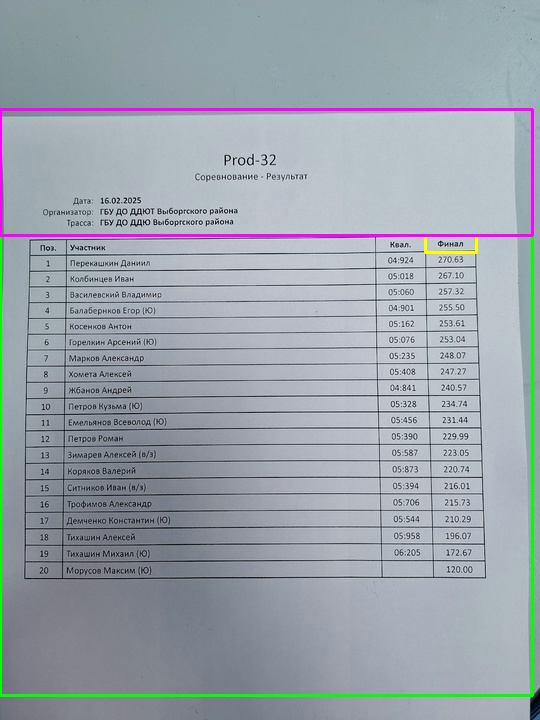

In [21]:
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

# Detect horizontal/vertical lines
kernel_h = np.ones((1, 20), np.uint8)
kernel_v = np.ones((20, 1), np.uint8)
horizontal = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_h)
vertical = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_v)

# Combine lines
grid = cv2.add(horizontal, vertical)

cells = []
# Find contours of cells
contours, _ = cv2.findContours(grid, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
max_rect = None
max_area = 0
inner_y_rect = None
inner_y_pos = 1e5
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    # for some reason the area is incorrect, so I use w * h
    area = cv2.contourArea(cnt)
    area = w * h
    if max_area < area:
      max_area = area
      max_rect = cnt
    if cv2.boundingRect(cnt) != cv2.boundingRect(max_rect) and inner_y_pos > y and w > h:
      inner_y_pos = y
      inner_y_rect = cnt
    cells.append((x,y,w,h))

x,y,w,h = cv2.boundingRect(max_rect)
left_x = x
right_x = x + w
upper_y = y
cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)  # Highlight cell
x,y,w,h = cv2.boundingRect(inner_y_rect)
lower_y = y
cv2.rectangle(img, (x, y), (x+w, y+h), (255, 255, 0), 2)  # Highlight cell

cv2.rectangle(img, (left_x, upper_y), (right_x, lower_y), (255, 0, 255), 2)

header_img = img[upper_y:lower_y, left_x:right_x]

img

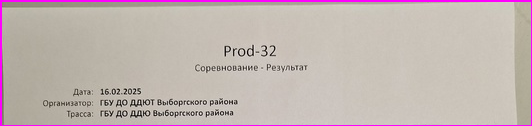

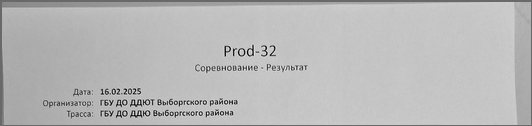

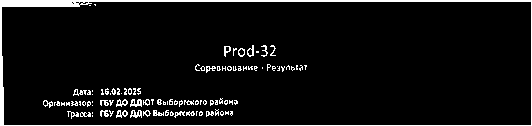

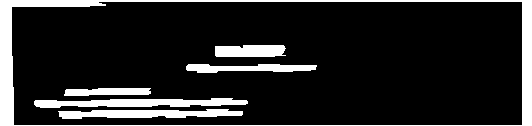

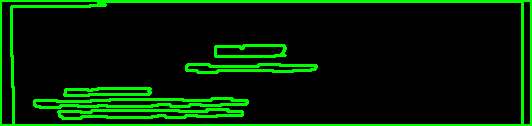

1850
2140
696
1179
852
67032
64000


array([[[255,   0, 255],
        [255,   0, 255],
        [255,   0, 255],
        ...,
        [255,   0, 255],
        [255,   0, 255],
        [255,   0, 255]],

       [[255,   0, 255],
        [255,   0, 255],
        [255,   0, 255],
        ...,
        [255,   0, 255],
        [255,   0, 255],
        [255,   0, 255]],

       [[255,   0, 255],
        [255,   0, 255],
        [118, 137, 144],
        ...,
        [154, 176, 181],
        [156, 178, 183],
        [255,   0, 255]],

       ...,

       [[255,   0, 255],
        [255,   0, 255],
        [112, 132, 137],
        ...,
        [150, 169, 176],
        [149, 169, 174],
        [255,   0, 255]],

       [[255,   0, 255],
        [255,   0, 255],
        [111, 131, 136],
        ...,
        [149, 168, 175],
        [149, 169, 174],
        [255,   0, 255]],

       [[255,   0, 255],
        [255,   0, 255],
        [255,   0, 255],
        ...,
        [255,   0, 255],
        [255,   0, 255],
        [255,   0, 255]]], dtype=uint8)
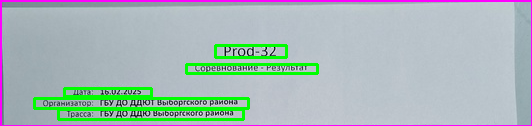

In [22]:
himg = header_img.copy()

gray = cv2.cvtColor(himg, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

# Create horizontal kernel to merge text in same line
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 1))
dilated = cv2.dilate(thresh, kernel, iterations=1)

cv2_imshow(himg)
cv2_imshow(gray)
cv2_imshow(thresh)
cv2_imshow(dilated)

# Find contours of text blocks
#contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#contours, _ = cv2.findContours(dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours, _ = cv2.findContours(dilated, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

contour_image = np.zeros_like(himg)
cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2)

cv2_imshow(contour_image)

lines = []
for cnt in contours:
  x, y, w, h = cv2.boundingRect(cnt)
  print(w * h)
  if w * h < 10_000:
    lines.append((x, y, w, h))
    cv2.rectangle(himg, (x, y), (x + w, y + h), (0, 255, 0), 2)

himg


In [23]:
import re
from datetime import datetime
hhimg = header_img.copy()

from string import ascii_letters, digits

russian = allowable_chars
all_chars = [f"{ascii_letters}{digits}-/", russian, f"{digits}.", russian ,russian]
langs = ["eng", "rus", "rus", "rus", "rus"]

margin = 3 # px

for line, a_chars, lang in zip(sorted(lines, key=lambda a: (a[1], a[0])), all_chars, langs):
  x, y, w, h = line
  line_img = hhimg[y-margin:y+h+margin, x-margin:x+w+margin]
  cv2_imshow(line_img)
  line_text = pytesseract.image_to_string(line_img, config=f"-c tessedit_char_whitelist={a_chars} -c preserve_interword_spaces=1", lang=lang)
  date_match = re.search(r"\b\d{2}\.\d{2}\.\d{4}\b", line_text.strip())
  corrected_date = datetime.strptime(date_match.group(0), "%d.%m.%Y").date() if date_match else line_text.strip()
  print(corrected_date)


Prod-32


СоревнованиеРезултат


2025-02-16


ОрганизаторГБУДОДДЮТВыборгскогорайона


ТрассаГБУДОДДЮВыборгскогорайома


In [273]:
from thefuzz import process

participants = [
    "Алексеев Устин",
    "Балабенков Егор",
    "Баранов Даниил",
    "Барг Лев",
    "Баталов Андрей",
    "Баталова Светлана",
    "Белолипецкий Алексей",
    "Битюков Федор",
    "Богданов Гавриил",
    "Братаев Михаил",
    "Василевский Владимир",
    "Васильев Егор",
    "Вульфсон Лев",
    "Горелкин Арсений",
    "Горелкин Евгений",
    "Демченко Константин",
    "Денисенко Георгий",
    "Дерезин Степан",
    "Дзавкаев Николай",
    "Дятлев Андрей",
    "Евстигнеев Александр",
    "Емельянов Всеволод",
    "Емельянов Михаил",
    "Ерошкин Виктор",
    "Жбанов Андрей",
    "Жмудик Никита",
    "Зайцев Семён",
    "Зенин Иван",
    "Зимарёв Алексей",
    "Ильичев Кирилл",
    "Истратук Иван",
    "Казарин Юрий",
    "Калашников Даниил",
    "Калинин Иван",
    "Козин Сергей",
    "Колбинцев Иван",
    "Корчмарский Георгий",
    "Коряков Валерий",
    "Косенков Антон",
    "Кривошеев Артём",
    "Кудряшов Артём",
    "Кулачковский Кирилл",
    "Ларуков Вадим",
    "Лебедев Дмитрий",
    "Лизиков Ростислав",
    "Лодягин Александр",
    "Лёнин Артём",
    "Майоров Артём",
    "Максютенко Михаил",
    "Малеваный Виктор",
    "Марков Александр",
    "Мартынова Ульяна",
    "Морусов Максим",
    "Неклюдов Владимир",
    "Нелюбин Александр",
    "Олейников Святослав",
    "Палехов Павел",
    "Перекашкин Даниил",
    "Перлов Михаил",
    "Петров Кузьма",
    "Петров Михаил",
    "Петров Роман",
    "Петрушевский Алексей",
    "Позднеев Николай",
    "Полторан Мирон",
    "Романова Вероника",
    "Рубцов Тимофей",
    "Рудаков Кирилл",
    "Румянцев Ярослав",
    "Рыков Лев",
    "Самсонов Артемий",
    "Ситнер Денис",
    "Ситников Иван",
    "Соур Марк",
    "Соур Роман",
    "Степанов Артём",
    "Строков Дмитрий",
    "Струков Александр",
    "Суханов Александр",
    "Табурин Михаил",
    "Тарасов Андрей",
    "Тарита Макар",
    "Терехов Даниил",
    "Тихашин Алексей",
    "Тихашин Михаил",
    "Толкачёв Антон",
    "Трофимов Александр",
    "Трофимов Константин",
    "Хомета Алексей",
    "Хромов Тимофей",
    "Чумаченко Серафим",
    "Чурюмова Полина",
    "Шемагонов Даниэль",
    "Шибаев Игорь",
    "Шульгин Глеб",
    "Яковлев Алексей",
]

def find_closest_participant(ocr_participant):
  guesses = ((guess, process.extractOne(guess, participants)) for guess in ocr_participant.strip().splitlines())
  ocr_text, (guessed, confidence) = max(guesses, key=lambda g: g[1][1], default=(ocr_participant, ("", 0)))
  return guessed, reduce_confidence(ocr_text, confidence)

def reduce_confidence(ocr_participant, confidence):
  n_upper = sum(ch.isupper() for ch in ocr_participant) - ocr_participant[~0:].isupper()
  if n_upper < 2:
    confidence -= 15
    if len(ocr_participant) < 8:
      confidence -= 15
  return max(confidence, 0)

race_types = [
    "Prod-24",
    "Production 1/24",
    "Prod-32",
    "F1-32",
    "ES-24",
    "ES-32",
    "Eurosport 1/32"
]

def find_closest_race_type(ocr_race_type):
  guess, probability = process.extractOne(ocr_race_type.strip(), race_types)
  if guess in ("Prod-24", "Production 1/24"):
    guess = "Prod-24"
  if guess in ("ES-32", "Eurosport 1/32"):
    guess = "ES-32"
  return guess, probability
  #return process.extractOne(ocr_race_type.strip(), race_types)

In [286]:
es24_folder = root / "race_results/es24"

In [ ]:
from operator import itemgetter
import re
from datetime import datetime
from string import ascii_letters, digits

def find_contours(thresh_img):
  # Detect horizontal/vertical lines
  kernel_h = np.ones((1, 20), np.uint8)
  kernel_v = np.ones((20, 1), np.uint8)
  horizontal = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_h)
  vertical = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_v)

  # Combine lines
  grid = cv2.add(horizontal, vertical)

  # Find contours of cells
  contours, _ = cv2.findContours(grid, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
  return contours

def filter_cnt(gray_img, cnt):
  x, y, w, h = cv2.boundingRect(cnt)
  iw, ih = gray_img.shape
  return w > h and 11 < w / h < 20 and 130 < np.median(gray[y:y+h, x:x+w]) < 230 and 0.9 < w * h / (iw * ih) * 100 < 2.9


font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.5
text_color = (0, 0, 255)  # Red
text_thickness = 2

def filter_header_cnt(himg, cnt):
  x, y, w, h = cv2.boundingRect(cnt)
  iw, ih, _ = himg.shape
  gray = cv2.cvtColor(himg, cv2.COLOR_BGR2GRAY)
  return w > h and 4 < w / h < 35 and 0.3 < w * h / (iw * ih) * 100 < 6 #and 130 < np.median(gray[y:y+h, x:x+w]) < 230

def show_contours(img):
  himg = img.copy()
  gray = cv2.cvtColor(himg, cv2.COLOR_BGR2GRAY)
  _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

  # Create horizontal kernel to merge text in same line
  kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 1))
  dilated = cv2.dilate(thresh, kernel, iterations=1)

  cv2_imshow(himg)
  cv2_imshow(gray)
  cv2_imshow(thresh)
  cv2_imshow(dilated)

  # Find contours of text blocks
  #contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  #contours, _ = cv2.findContours(dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
  contours, _ = cv2.findContours(dilated, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

  contour_image = np.zeros_like(himg)
  cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2)
  cv2_imshow(contour_image)

  hhimg = himg.copy()
  ih, iw, _ = hhimg.shape
  for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    print(w * h, w*h / (iw*ih)*100, round(w/h, 3))
#    if w * h < 10_000:
#      lines.append((x, y, w, h))
    cv2.rectangle(hhimg, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(hhimg, f"{w * h} {w*h / (iw*ih):.2%} {w / h:.3f}", (x, y+20), font, font_scale, text_color, text_thickness)
  cv2_imshow(hhimg)

def show_ccontours(img, contours):
  hhimg = img.copy()
  for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    #print(w * h, w*h / (iw*ih)*100, round(w/h, 3))
    cv2.rectangle(hhimg, (x, y), (x + w, y + h), (0, 255, 0), 2)
    #cv2.putText(hhimg, f"{w * h} {w*h / (iw*ih):.2%} {w / h:.3f}", (x, y+20), font, font_scale, text_color, text_thickness)
  cv2_imshow(hhimg)

def parse_header(img, upper_y_cell):
  x, y, w, h = cv2.boundingRect(upper_y_cell)
  ih, iw, _ = img.shape
  #print(ih, y, round(y / ih * 100,3 ))
  y_b = 0
  if y / ih > 0.18:
    # make the header 18% at max of the image height
    y_b = int(ih * (y/ih - 0.18))
  himg = img[y_b:y].copy()

  gray = cv2.cvtColor(himg, cv2.COLOR_BGR2GRAY)
  _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

  # Create horizontal kernel to merge text in same line
  kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 1))
  dilated = cv2.dilate(thresh, kernel, iterations=1)

  # Find contours of text blocks
  #contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  #contours, _ = cv2.findContours(dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
  contours, _ = cv2.findContours(dilated, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

  contour_image = np.zeros_like(himg)
  cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2)

  contours = sorted((cnt for cnt in contours if filter_header_cnt(himg, cnt)), key=lambda c: cv2.boundingRect(c)[1::-1])

  #show_contours(himg)
  #show_ccontours(himg, contours)

  race_type_cnt = contours[0]
  race_date_cnt = contours[2]

  margin=3
  race_type_margin=6
  date_margin = 2 # px

  x,y,w,h = cv2.boundingRect(race_type_cnt)
  t_img = himg[y-race_type_margin:y+h+race_type_margin, x-margin:x+w+margin]
  ocr_race_type = pytesseract.image_to_string(t_img, config=f"-c tessedit_char_whitelist={ascii_letters}{digits}-/ -c preserve_interword_spaces=1", lang="eng")
  race_type = find_closest_race_type(ocr_race_type)
  #print(race_type)
  cv2_imshow(t_img)

  x,y,w,h = cv2.boundingRect(race_date_cnt)
  t_img = himg[y-date_margin:y+h+date_margin, x+int(w/3)-margin:x+w+margin]
  ocr_date = pytesseract.image_to_string(t_img, config=f"-c tessedit_char_whitelist={digits}. -c preserve_interword_spaces=1", lang="eng")
  date_match = re.search(r"\b\d{2}\.\d{2}\.\d{4}\b", ocr_date.strip())
  try:
    race_date = datetime.strptime(date_match.group(0), "%d.%m.%Y").date() if date_match else ocr_date.strip()
  except ValueError:
    race_date = ""
  if not race_date:
    t_img = t_img.copy()
    h, w, _ = t_img.shape
    center = (w//2, h//2)

    M = cv2.getRotationMatrix2D(center, -2, 1.0)
    #t_img = cv2.warpAffine(t_img, M, (w, h), borderValue=(255, 255, 255))
    t_img = cv2.resize(t_img, (w * 2, h*2), interpolation=cv2.INTER_CUBIC)
    ocr_date = pytesseract.image_to_string(t_img, config=f"-c tessedit_char_whitelist={digits}. -c preserve_interword_spaces=1", lang="eng")
    date_match = re.search(r"\b\d{2}\.\d{2}\.\d{4}\b", ocr_date.strip())
    race_date = datetime.strptime(date_match.group(0), "%d.%m.%Y").date() if date_match else ocr_date.strip()
  #print(race_date)
  cv2_imshow(t_img)

  return race_type, race_date


margin = 3
resize_coeff = 2

for es24_img in es24_folder.iterdir():
  img = cv2.imread(es24_img)
  if img is None:
    continue
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

  font = cv2.FONT_HERSHEY_SIMPLEX
  font_scale = 0.5
  text_color = (0, 0, 255)  # Red
  text_thickness = 2

  cells = []
  iw, ih, _ = img.shape
  # Find contours of cells
  contours = find_contours(thresh)
  n_cnt = 0
  success = 0
  cnt_x_y = ((cnt, cv2.boundingRect(cnt)[:2]) for cnt in contours)
  cnt_x_y = sorted(cnt_x_y, key=lambda c: (c[1][1], c[1][0]))
  contours = [cnt for cnt, _ in cnt_x_y if filter_cnt(gray, cnt)]

  print(es24_img.name)
  race_type, date = parse_header(img, contours[0])
  print(race_type, repr(date))
  continue

  for cnt, _ in cnt_x_y:
      x, y, w, h = cv2.boundingRect(cnt)
      area = cv2.contourArea(cnt)
      if not filter_cnt(gray, cnt):
        continue
      n_cnt += 1
      cells.append((x,y,w,h))
      t_img = img[y+margin:y+h-margin, x+margin:x+int(w/2)-margin].copy()
      line_text = pytesseract.image_to_string(t_img, config=f"-c tessedit_char_whitelist={allowable_chars+' '} -c preserve_interword_spaces=1", lang=lang)
      if not line_text.strip():
        t_img = cv2.resize(t_img, (int(w/2) * resize_coeff, h * resize_coeff), interpolation=cv2.INTER_CUBIC)
        line_text = pytesseract.image_to_string(t_img, config=f"-c tessedit_char_whitelist={allowable_chars+' '} -c preserve_interword_spaces=1", lang=lang)
      #cv2_imshow(t_img)
      print(f"{line_text.strip()!r}, {find_closest_participant(line_text)}")
      if line_text.strip():
        success += 1
      #cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)  # Highlight cell
      #cv2.putText(img, line_text.strip(), (x+ 50, y + 20), cv2.FONT_HERSHEY_COMPLEX, font_scale, text_color, text_thickness)
      #cv2.putText(img, f"{w * h} {w*h / (iw*ih):.2%} {w / h:.3f} {np.median(gray[y:y+h, x:x+w])}", (x, y+20), font, font_scale, text_color, text_thickness)
  print(f"success rate {success} / {n_cnt} ({success / n_cnt:.2%})")
  print(n_cnt)
  print(es24_img)
  print()
  #cv2_imshow(img)